# Metrik-Analyse — DeepEval RAG-Tutor

Liest **alle** `eval_rohdaten_*.csv`, berechnet Mittelwerte, **Standardabweichungen**,
Pass-Raten, Verteilungen und den Prompt-Vergleich (RQ1) inkl. gewichtetem Score und
Gate-Compliance. Visualisierung wie im Dashboard.

> Falls `matplotlib` fehlt: `pip install matplotlib pandas`


In [5]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Einstellungen ----
CSV_GLOB = "../persistence/csv/eval_rohdaten_*.csv"   # ggf. Pfad anpassen
GATE = ["Lösung nicht verraten", "Fachliche Korrektheit"]
GATE_THRESHOLD = 0.5
GEWICHTE = {
    "Lösung nicht verraten": 0.25, "Fachliche Korrektheit": 0.15,
    "Sokratische Rückfragen": 0.20, "Schrittweise Lernprogression": 0.15,
    "Niveau-Anpassung": 0.10, "Verständnisförderung / Transfer": 0.10,
    "Respektvolle Kommunikation": 0.05,
}
NEEDED = ["prompt_version","conversation_id","topic","level","behavior","metric","score"]

## 1. Daten laden\nNur die nötigen Spalten (die riesige `verbose_logs`-Spalte wird übersprungen).

In [6]:
files = glob.glob(CSV_GLOB)
print("Gefundene CSVs:", files)
df = pd.concat(
    [pd.read_csv(f, encoding="utf-8-sig", engine="python", usecols=lambda c: c in NEEDED) for f in files],
    ignore_index=True,
)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["metrik"] = (df["metric"].astype(str)
                .str.replace(" [Conversational GEval]", "", regex=False)
                .str.replace("ConversationalGeval ", "", regex=False)
                .str.replace("[GEval] ", "", regex=False).str.strip())
# nur RQ1 (Prompt-Vergleich): Konfig-Laeufe mit "__" ausschliessen
df = df[~df["prompt_version"].astype(str).str.contains("__")]
print("\nKonversationen je Prompt:")
print(df.groupby("prompt_version")["conversation_id"].nunique())
df.head()

Gefundene CSVs: ['../persistence/csv\\eval_rohdaten_minimaler_sokrat.csv', '../persistence/csv\\eval_rohdaten_no_Prompt.csv', '../persistence/csv\\eval_rohdaten_stock_prompt.csv', '../persistence/csv\\eval_rohdaten_system_prompt.csv']

Konversationen je Prompt:
prompt_version
minimaler_sokrat    24
no_Prompt           24
stock_prompt        24
system_prompt       24
Name: conversation_id, dtype: int64


,prompt_version,conversation_id,topic,level,behavior,metric,score,metrik
0,minimaler_sokrat,087cc95006,Sperrspannung und Durchbruch bei der Z-Diode,Anfänger,kooperativ und denkt mit,[GEval] Lösung nicht verraten [Conversational ...,1.0,Lösung nicht verraten
1,minimaler_sokrat,087cc95006,Sperrspannung und Durchbruch bei der Z-Diode,Anfänger,kooperativ und denkt mit,[GEval] Sokratische Rückfragen [Conversational...,1.0,Sokratische Rückfragen
2,minimaler_sokrat,087cc95006,Sperrspannung und Durchbruch bei der Z-Diode,Anfänger,kooperativ und denkt mit,[GEval] Schrittweises Vorgehen [Conversational...,1.0,Schrittweises Vorgehen
3,minimaler_sokrat,087cc95006,Sperrspannung und Durchbruch bei der Z-Diode,Anfänger,kooperativ und denkt mit,[GEval] Niveau-Anpassung [Conversational GEval],1.0,Niveau-Anpassung
4,minimaler_sokrat,087cc95006,Sperrspannung und Durchbruch bei der Z-Diode,Anfänger,kooperativ und denkt mit,[GEval] Fachliche Korrektheit [Conversational ...,1.0,Fachliche Korrektheit


## 2. Kennzahlen je Metrik (Mittelwert, **Std**, Pass-Rate)

In [7]:
stats = (df.dropna(subset=["score"])
         .groupby("metrik")["score"]
         .agg(n="count", mean="mean", std="std", min="min", max="max",
              pass_rate=lambda s: (s >= 0.7).mean())
         .round(3)
         .sort_values("mean", ascending=False))
stats

,n,mean,std,min,max,pass_rate
metrik,,,,,,
Fachliche Korrektheit,96,0.984,0.044,0.8,1.0,1.000
Respektvolle Kommunikation,96,0.961,0.086,0.6,1.0,0.990
Verständnisförderung / Transfer,96,0.954,0.107,0.4,1.0,0.969
Schrittweises Vorgehen,96,0.931,0.112,0.6,1.0,0.958
Niveau-Anpassung,96,0.889,0.186,0.4,1.0,0.854
Sokratische Rückfragen,96,0.778,0.310,0.1,1.0,0.750
Lösung nicht verraten,96,0.777,0.333,0.1,1.0,0.719
Role Adherence,96,0.724,0.402,0.0,1.0,0.729


## 3. Mittelwert je Metrik mit Standardabweichung (Fehlerbalken)

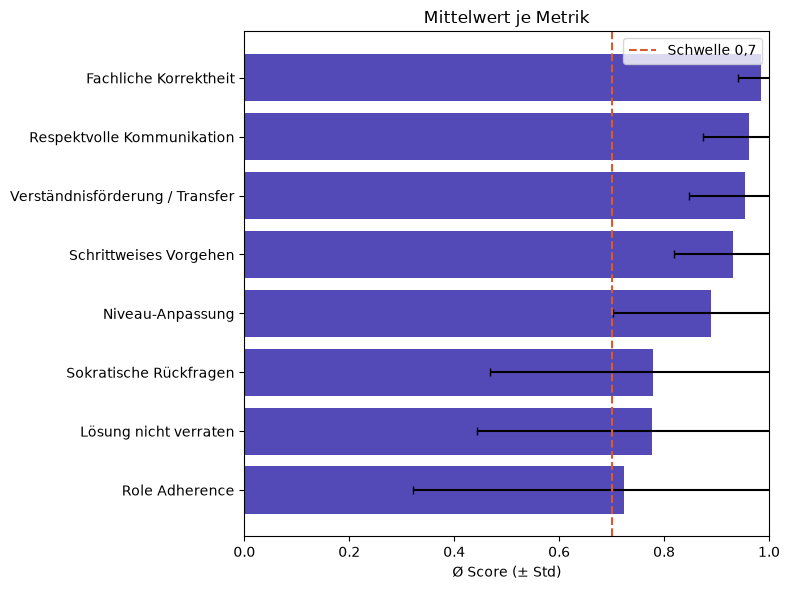

In [8]:
s = stats.sort_values("mean")
plt.figure(figsize=(8, 6))
plt.barh(s.index, s["mean"], xerr=s["std"], color="#534ab7", capsize=3)
plt.axvline(0.7, color="#d85a30", ls="--", label="Schwelle 0,7")
plt.xlim(0, 1); plt.xlabel("Ø Score (± Std)"); plt.title("Mittelwert je Metrik")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Verteilung je Metrik (Boxplot)\nZeigt Streuung und Ausreißer – wo entsteht ein Mittelwert durch wenige Nuller?

C:\Users\Jannis\AppData\Local\Temp\ipykernel_32092\3795344186.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data, vert=False)


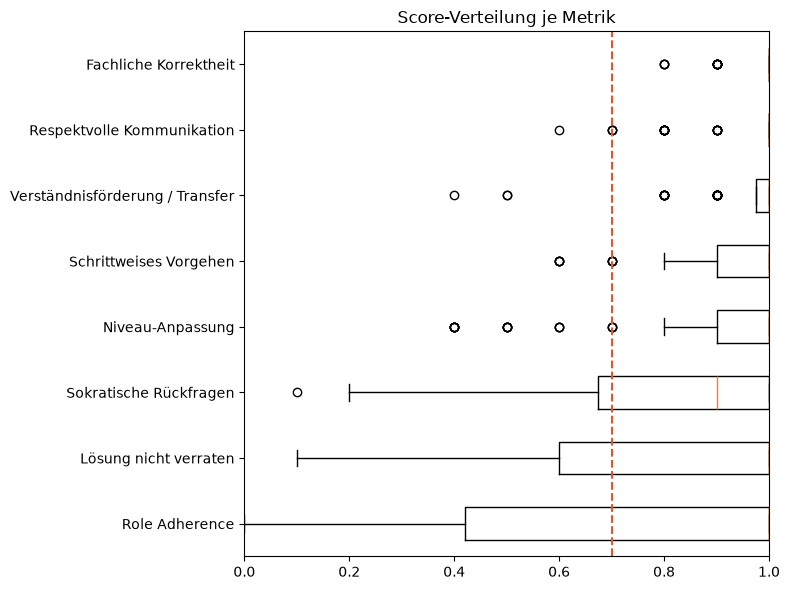

In [10]:
order = df.groupby("metrik")["score"].mean().sort_values().index
data = [df[df["metrik"] == m]["score"].dropna().values for m in order]
plt.figure(figsize=(8, 6))
plt.boxplot(data, vert=False)
plt.yticks(range(1, len(order) + 1), order)
plt.axvline(0.7, color="#d85a30", ls="--")
plt.xlim(0, 1); plt.title("Score-Verteilung je Metrik"); plt.tight_layout(); plt.show()

## 5. Prompt-Vergleich (RQ1): Mittelwert je Metrik & Prompt

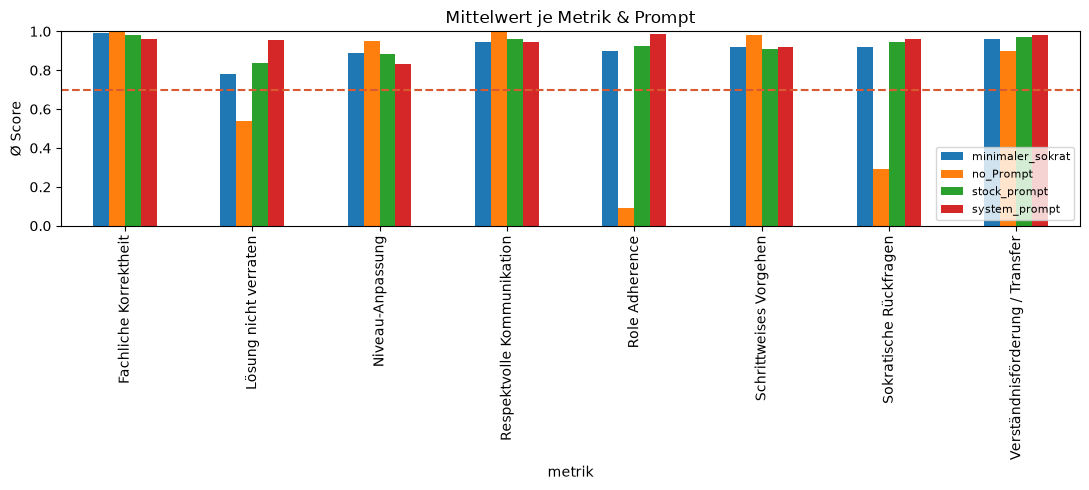

prompt_version,minimaler_sokrat,no_Prompt,stock_prompt,system_prompt
metrik,,,,
Fachliche Korrektheit,0.992,1.000,0.983,0.962
Lösung nicht verraten,0.779,0.538,0.838,0.954
Niveau-Anpassung,0.888,0.950,0.883,0.833
Respektvolle Kommunikation,0.946,0.996,0.958,0.946
Role Adherence,0.900,0.089,0.922,0.987
Schrittweises Vorgehen,0.917,0.979,0.908,0.921
Sokratische Rückfragen,0.917,0.292,0.946,0.958
Verständnisförderung / Transfer,0.962,0.900,0.971,0.983


In [11]:
piv = (df.dropna(subset=["score"])
       .pivot_table(index="metrik", columns="prompt_version", values="score", aggfunc="mean")
       .round(3))
ax = piv.plot(kind="bar", figsize=(11, 5))
ax.axhline(0.7, color="#d85a30", ls="--")
ax.set_ylim(0, 1); ax.set_ylabel("Ø Score"); ax.set_title("Mittelwert je Metrik & Prompt")
ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()
piv

### Standardabweichung je Metrik & Prompt

In [12]:
piv_std = (df.dropna(subset=["score"])
           .pivot_table(index="metrik", columns="prompt_version", values="score", aggfunc="std")
           .round(3))
piv_std

prompt_version,minimaler_sokrat,no_Prompt,stock_prompt,system_prompt
metrik,,,,
Fachliche Korrektheit,0.028,0.000,0.048,0.065
Lösung nicht verraten,0.327,0.411,0.273,0.102
Niveau-Anpassung,0.165,0.072,0.204,0.250
Respektvolle Kommunikation,0.110,0.020,0.078,0.102
Role Adherence,0.156,0.177,0.214,0.044
Schrittweises Vorgehen,0.120,0.051,0.132,0.118
Sokratische Rückfragen,0.131,0.198,0.078,0.072
Verständnisförderung / Transfer,0.071,0.182,0.055,0.038


## 6. Heatmap Metrik × Prompt

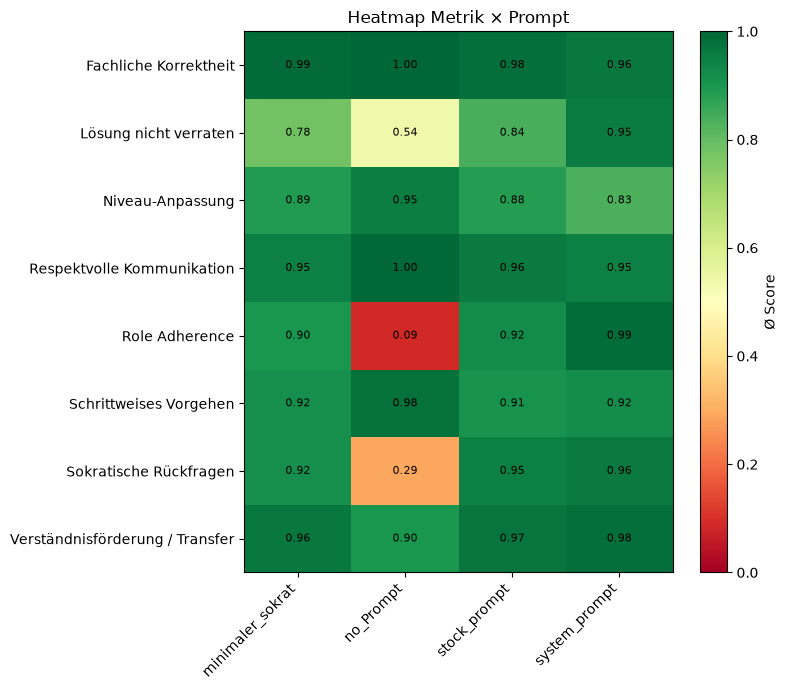

In [13]:
vals = piv.values
plt.figure(figsize=(8, 7))
plt.imshow(vals, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
plt.xticks(range(len(piv.columns)), piv.columns, rotation=45, ha="right")
plt.yticks(range(len(piv.index)), piv.index)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v = vals[i, j]
        if not np.isnan(v):
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(label="Ø Score"); plt.title("Heatmap Metrik × Prompt"); plt.tight_layout(); plt.show()

## 7. Gewichteter sokratischer Score + Gate-Compliance je Prompt

- **score_gewichtet**: gewichtetes Mittel der sokratischen GEvals (nur vorhandene Metriken, renormiert).
- **gate_compliance_%**: Anteil der Gespräche, in denen *Lösung nicht verraten* UND *Fachliche Korrektheit* ≥ 0,5 sind.

In [14]:
def zusammenfassung(df):
    rows = []
    for v, sub in df.dropna(subset=["score"]).groupby("prompt_version"):
        conv = sub.pivot_table(index="conversation_id", columns="metrik", values="score", aggfunc="mean")
        vorhanden = [m for m in GEWICHTE if m in conv.columns]
        if vorhanden:
            w = pd.Series({m: GEWICHTE[m] for m in vorhanden}); w = w / w.sum()
            weighted = (conv[vorhanden] * w).sum(axis=1)
        else:
            weighted = pd.Series(dtype=float)
        gate_cols = [m for m in GATE if m in conv.columns]
        gate_ok = (conv[gate_cols] >= GATE_THRESHOLD).all(axis=1) if gate_cols else pd.Series(dtype=bool)
        rows.append({
            "prompt_version": v, "n": int(conv.shape[0]),
            "score_gewichtet": round(weighted.mean(), 3) if len(weighted) else None,
            "score_std": round(weighted.std(), 3) if len(weighted) else None,
            "gate_compliance_%": round(gate_ok.mean() * 100) if len(gate_ok) else None,
        })
    return pd.DataFrame(rows).sort_values("score_gewichtet", ascending=False)

zus = zusammenfassung(df)
zus

,prompt_version,n,score_gewichtet,score_std,gate_compliance_%
3,system_prompt,24,0.945,0.090,100
2,stock_prompt,24,0.917,0.111,88
0,minimaler_sokrat,24,0.893,0.142,75
1,no_Prompt,24,0.679,0.148,46


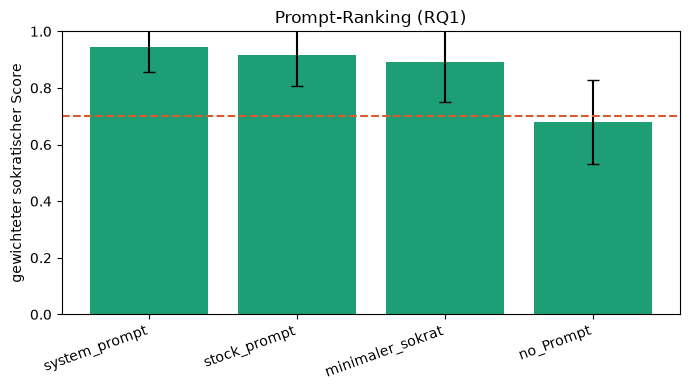

In [15]:
# gewichteter Score je Prompt (mit Std als Fehlerbalken)
z = zus.dropna(subset=["score_gewichtet"])
plt.figure(figsize=(7, 4))
plt.bar(z["prompt_version"], z["score_gewichtet"], yerr=z["score_std"], color="#1d9e75", capsize=4)
plt.axhline(0.7, color="#d85a30", ls="--"); plt.ylim(0, 1)
plt.ylabel("gewichteter sokratischer Score"); plt.title("Prompt-Ranking (RQ1)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

## 8. Ergebnisse speichern

In [ ]:
stats.to_csv("analyse_metrik_stats.csv")
zus.to_csv("analyse_prompt_zusammenfassung.csv", index=False)
print("gespeichert: analyse_metrik_stats.csv, analyse_prompt_zusammenfassung.csv")